# Loss Landscape Visualization

Sweeps all pairs of trainable AdEx parameters over a grid, simulates at each point,
and plots the loss surfaces as:
1. A lower-triangle grid of 2D contour plots (21 pairs)
2. Individual 3D surface plots with contour projection (Ackley-style)

In [1]:
import copy
import logging
import time
from itertools import combinations

import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from jax import config

from ADoptEX.core import simulate_jaxley
from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    GuarinoFeatures,
    GuarinoLossConfig,
    VanRossumLossConfig,
    extract_experimental_features,
    guarino_loss,
    make_guarino_loss_fn,
    make_van_rossum_loss_fn,
    spike_train_from_voltage,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_plot,
    trace_stim_window_plot,
    training_comparison_plot,
    training_history_plot,
)
from ADoptEX.training import TrainingResult
from ADoptEX.training.trainer import TrainingConfig, setup_trainable_cell, train

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

import matplotlib.pyplot as plt
from matplotlib import cm


## 1. Load & Crop Data

In [2]:
initial_params = dict(NAUD_PARAMETERS["adaptation"])
initial_params["v_threshold"] = 0.0
print(initial_params)

current_pA = initial_params["I"]

t_max_ms = 100
dt_ms = 0.025
T = np.linspace(0, t_max_ms, int(t_max_ms / dt_ms))

sim_init = simulate_jaxley(
    params=initial_params,
    stim_current_pA=current_pA,
    stim_duration_ms=100,
    dt_ms=dt_ms,
    t_max_ms=t_max_ms,
    stim_delay_ms=0.0,
    use_surrogate=False,
)

SPIKE_PEAK_MV = 35.0
for st in sim_init.spike_times:
    idx = int(st / dt_ms)
    if 0 <= idx < len(sim_init.voltage):
        sim_init.voltage[idx] = SPIKE_PEAK_MV

T = np.append(T, T[-1] + dt_ms)
print(len(T))

INFO:2026-04-22 13:30:39,906:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


{'C_m': 200.0, 'g_L': 12.0, 'E_L': -70.0, 'v_T': -50.0, 'delta_T': 2.0, 'v_reset': -58.0, 'v_threshold': 0.0, 'tau_w': 300.0, 'a': 2.0, 'b': 60.0, 'I': 500.0}


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 external_states. See `.externals` for details.
4001


## 2. Setup Cell & Loss Function

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Number of newly added trainable parameters: 1. Total number of trainable parameters: 7
Number of newly added trainable parameters: 1. Total number of trainable parameters: 8
Initial loss: 0.0000
Trainable parameters (8): ['capacitance', 'g_L', 'E_L', 'v_T', 'v_reset', 'tau_w', 'a', 'b']
Initial parameters: {'C_m': 200.0, 'g

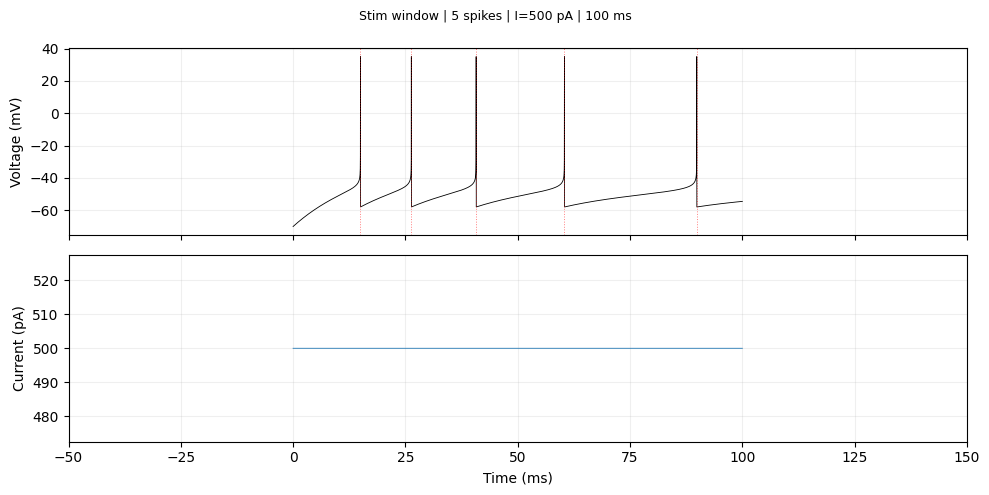

In [3]:
from ADoptEX.loss import (
    extract_experimental_features,
    GuarinoLossConfig,
    make_guarino_loss_fn, MSELossConfig, make_mse_loss_fn,
)

training_config = TrainingConfig(
    optimizer="adam",
    learning_rate=0.01,
    n_epochs=1,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
)

trace_stim_window_plot(TraceData(
    T,
    sim_init.voltage,
    np.full(len(T), initial_params["I"]),
    dt_ms,
    sim_init.spike_times,
    0,
    len(T),
    initial_params["I"]))

cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=np.full(len(T), initial_params["I"]),
    dt_ms=dt_ms,
    config=training_config,
)

target_voltage = jnp.array(sim_init.voltage)
stim_end_index = len(sim_init.voltage)

loss_name = 'MSE'
loss_fn = make_mse_loss_fn(
    cell=cell,
    data_stimuli=data_stimuli,
    t_max=t_max,
    dt_ms=dt_ms,
    exp_voltage=target_voltage,
    stim_end_index=stim_end_index,
    loss_config=MSELossConfig(normalize=False, clamp_threshold=None, spike_peak_mv=SPIKE_PEAK_MV),
)

# Build param name -> index mapping
param_index = {}
for i, p in enumerate(trainable_params):
    for k in p:
        param_index[k.replace("AdEx_", "")] = i

PARAM_NAMES = list(param_index.keys())
N_PARAMS = len(PARAM_NAMES)

loss_init = loss_fn(trainable_params)
print(f"Initial loss: {float(loss_init):.4f}")
print(f"Trainable parameters ({N_PARAMS}): {PARAM_NAMES}")
print(f"Initial parameters: {initial_params}")


## 3. Sweep All Parameter Pairs

For each of the C(7,2) = 21 pairs, build a grid over their PARAM_BOUNDS and
evaluate the loss. Non-swept parameters stay at their default values.

In [4]:
GRID_SIZE = 10  # 20x20 per pair; 21 pairs * 400 = 8400 simulations

pairs = list(combinations(range(N_PARAMS), 2))
print(f"{len(pairs)} parameter pairs, {GRID_SIZE}x{GRID_SIZE} grid each")
print(f"Total simulations: {len(pairs) * GRID_SIZE**2}")

28 parameter pairs, 10x10 grid each
Total simulations: 2800


In [5]:
# Storage for all grids
grids = {}  # (i, j) -> {"X": ..., "Y": ..., "Z": ...}

t_start = time.time()

for pair_idx, (pi, pj) in enumerate(pairs):
    px, py = PARAM_NAMES[pi], PARAM_NAMES[pj]
    bx, by = PARAM_BOUNDS[px], PARAM_BOUNDS[py]

    x_vals = np.linspace(bx.min, bx.max, GRID_SIZE)
    y_vals = np.linspace(by.min, by.max, GRID_SIZE)
    X, Y = np.meshgrid(x_vals, y_vals)
    Z = np.full((GRID_SIZE, GRID_SIZE), np.nan)

    ix, iy = param_index[px], param_index[py]

    pxrc = f"AdEx_{px}" if px != "capacitance" else px
    pyrc = f"AdEx_{py}" if py != "capacitance" else py
    for r in range(GRID_SIZE):
        for c in range(GRID_SIZE):
            params_rc = copy.deepcopy(trainable_params)
            params_rc[ix] = {pxrc: jnp.array([X[r, c]])}
            params_rc[iy] = {pyrc: jnp.array([Y[r, c]])}
            try:
                Z[r, c] = float(loss_fn(params_rc))
            except Exception:
                Z[r, c] = np.nan

    grids[(pi, pj)] = {"X": X, "Y": Y, "Z": Z}

    elapsed = time.time() - t_start
    eta = elapsed / (pair_idx + 1) * (len(pairs) - pair_idx - 1)
    print(
        f"  [{pair_idx+1:2d}/{len(pairs)}] {px:>8s} vs {py:<8s}  "
        f"loss=[{np.nanmin(Z):.1f}, {np.nanmax(Z):.1f}]  "
        f"elapsed={elapsed:.0f}s  ETA={eta:.0f}s"
    )

print(f"\nTotal time: {time.time() - t_start:.0f}s")

  [ 1/28] capacitance vs g_L       loss=[33.9, 86.9]  elapsed=12s  ETA=337s
  [ 2/28] capacitance vs E_L       loss=[33.4, 337.2]  elapsed=25s  ETA=321s
  [ 3/28] capacitance vs v_T       loss=[34.3, 259.0]  elapsed=37s  ETA=310s
  [ 4/28] capacitance vs v_reset   loss=[30.5, 1073.9]  elapsed=50s  ETA=298s
  [ 5/28] capacitance vs tau_w     loss=[39.4, 98.6]  elapsed=62s  ETA=286s
  [ 6/28] capacitance vs a         loss=[35.3, 65.6]  elapsed=75s  ETA=275s
  [ 7/28] capacitance vs b         loss=[36.9, 457.8]  elapsed=89s  ETA=267s
  [ 8/28]      g_L vs E_L       loss=[28.1, 537.7]  elapsed=102s  ETA=255s
  [ 9/28]      g_L vs v_T       loss=[31.4, 182.6]  elapsed=115s  ETA=243s
  [10/28]      g_L vs v_reset   loss=[33.2, 234.8]  elapsed=129s  ETA=232s
  [11/28]      g_L vs tau_w     loss=[25.1, 66.4]  elapsed=142s  ETA=219s
  [12/28]      g_L vs a         loss=[23.4, 64.1]  elapsed=155s  ETA=207s
  [13/28]      g_L vs b         loss=[24.9, 77.3]  elapsed=170s  ETA=196s
  [14/28]      E

## 4. Triangle Grid — All Pairs (2D Contour)

Lower-triangle matrix: row = second parameter, column = first parameter.
Each cell shows a filled contour of the loss landscape for that pair.

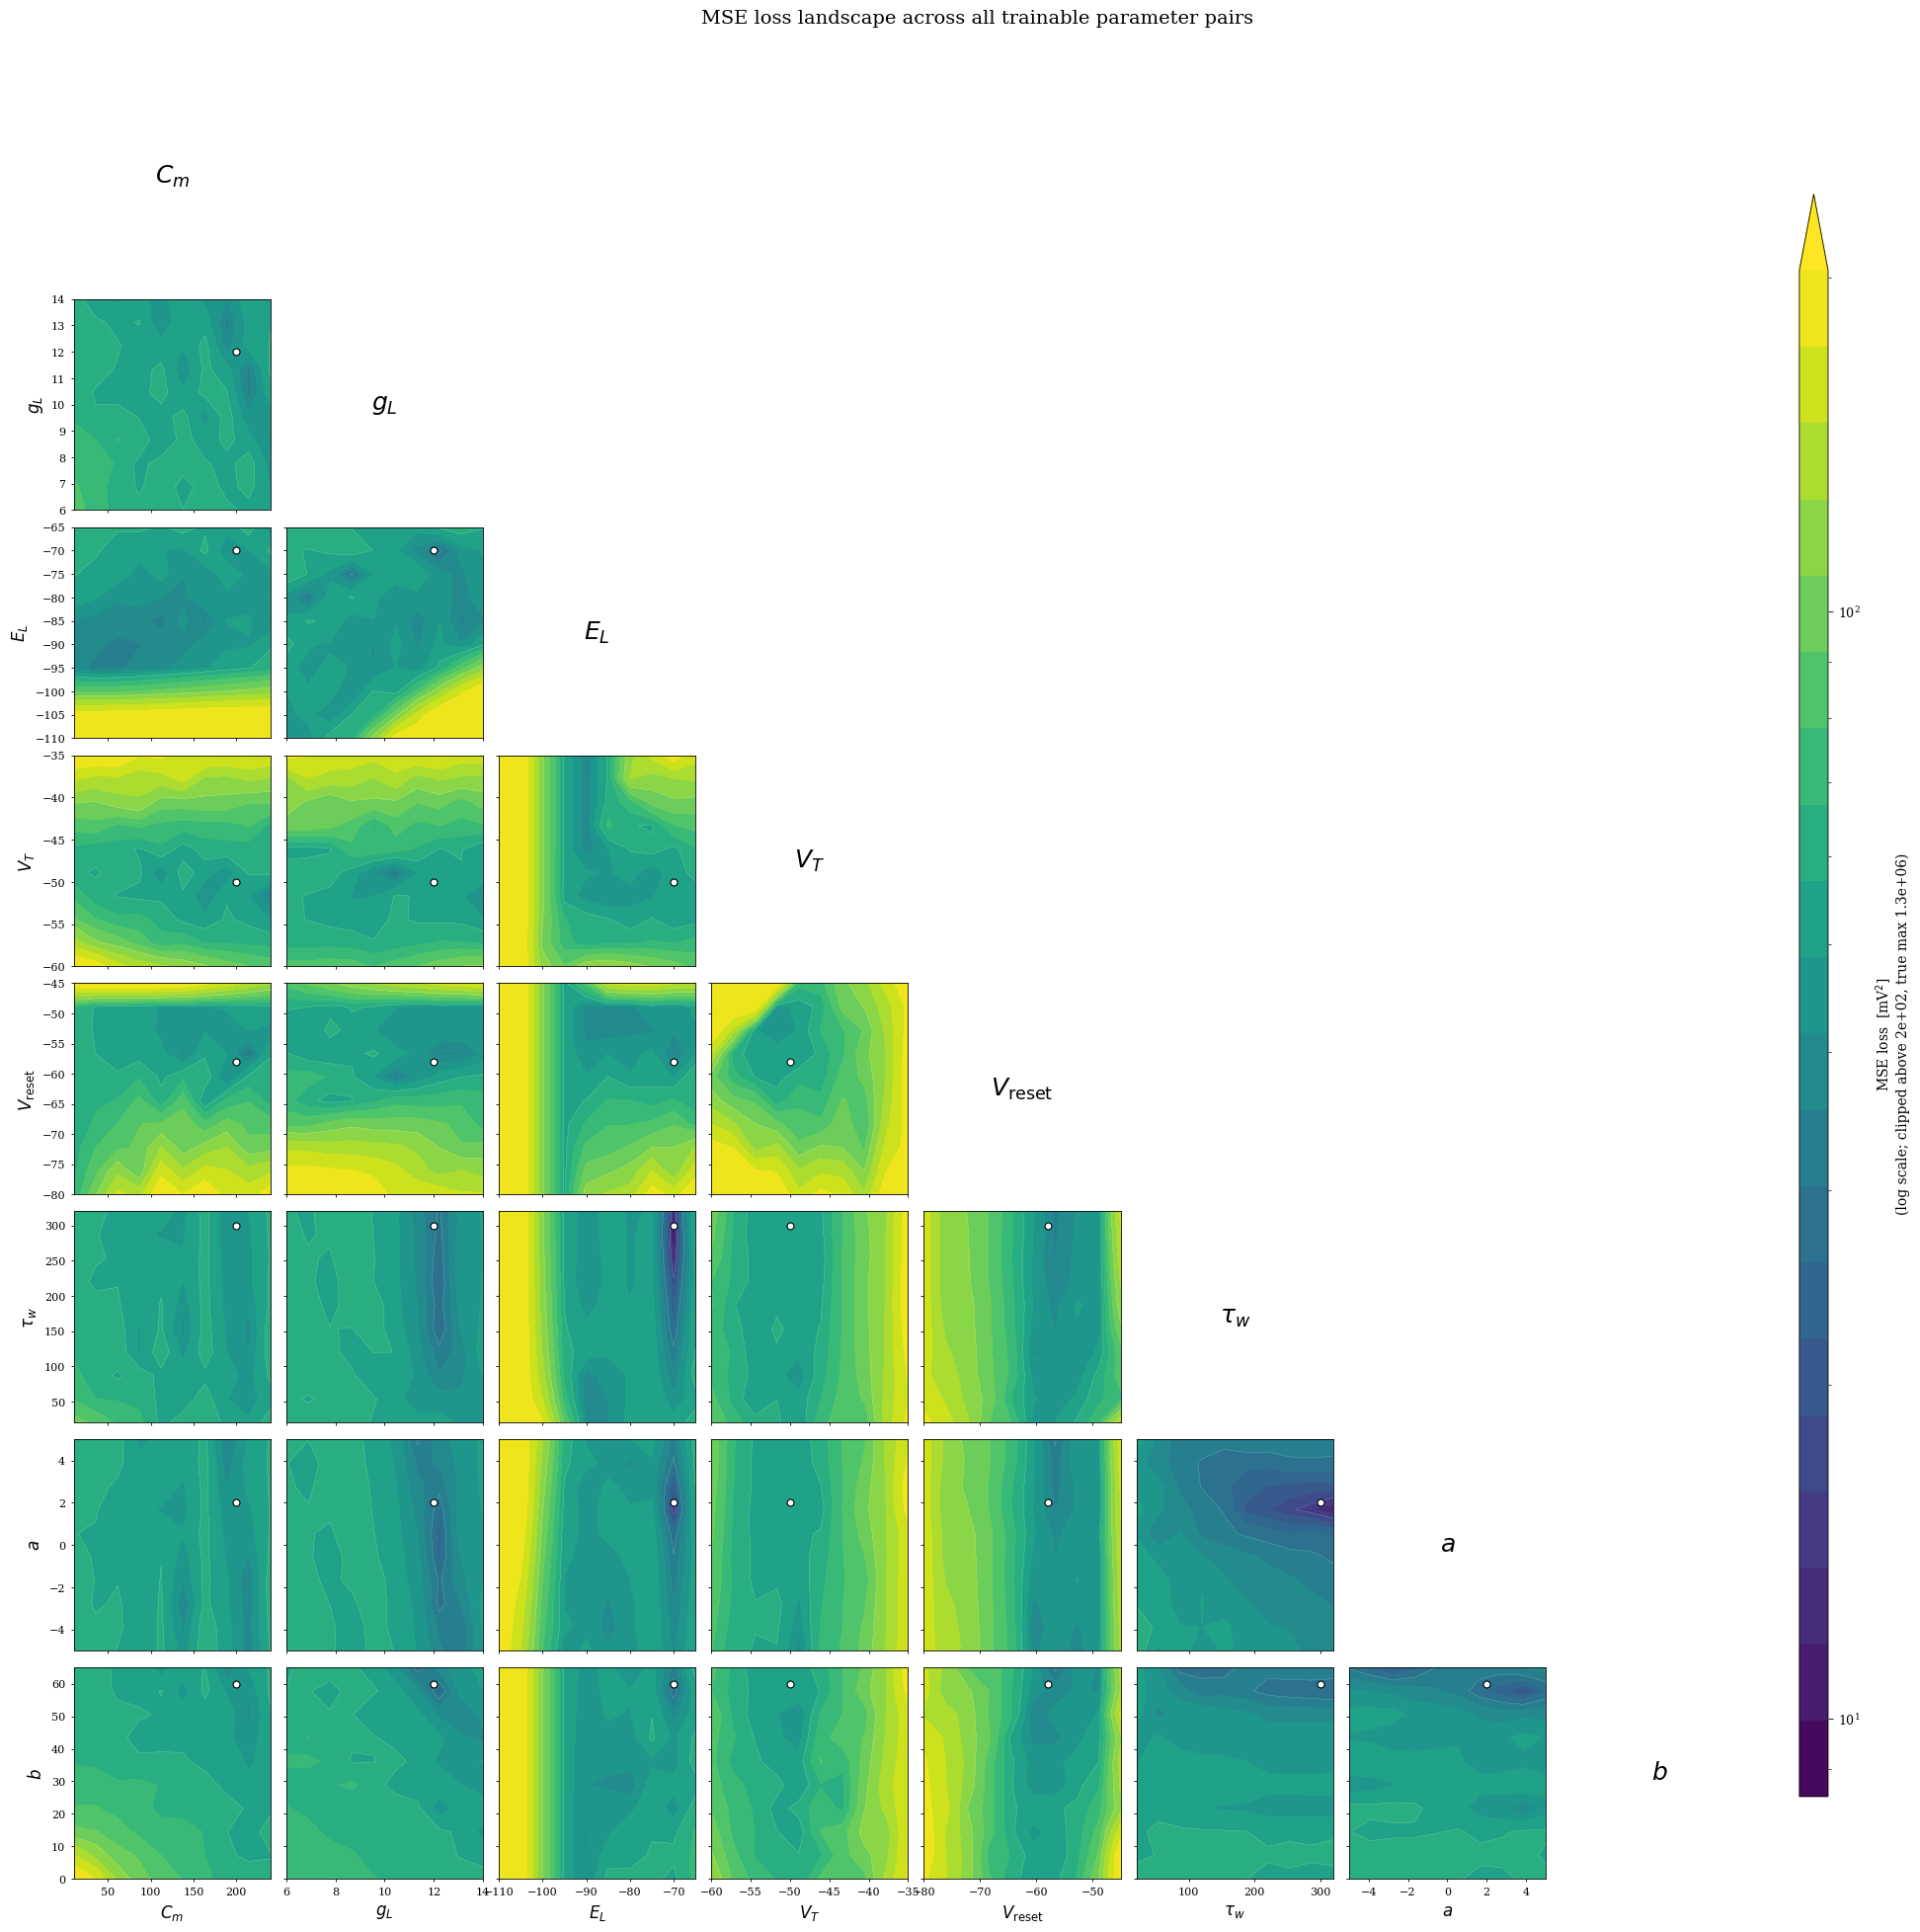

Saved to mse_loss_landscape_grid.pdf
Loss range across all pairs: [8.5, 1.28e+06] mV^2
Colorbar clip at 95th percentile: 203 mV^2


In [6]:
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

# Math-formatted labels for thesis presentation
PARAM_LABELS = {
    "capacitance": r"$C_m$",
    "g_L": r"$g_L$",
    "E_L": r"$E_L$",
    "v_T": r"$V_T$",
    "delta_T": r"$\Delta_T$",
    "v_reset": r"$V_\mathrm{reset}$",
    "tau_w": r"$\tau_w$",
    "a": r"$a$",
    "b": r"$b$",
}

def _map_name_to_initial(s):
    return "C_m" if s == "capacitance" else s

# Global log-scale color across all pairs (clipped at 95th percentile to tame outliers)
all_Z = np.concatenate([g["Z"].ravel() for g in grids.values()])
positive = all_Z[np.isfinite(all_Z) & (all_Z > 0)]
vmin = float(np.min(positive)) if positive.size else 1e-6
vmax_clip = float(np.nanpercentile(all_Z, 95))
vmax_clip = max(vmax_clip, vmin * 10)  # guarantee at least one decade
vmax_true = float(np.nanmax(all_Z))
norm = LogNorm(vmin=vmin, vmax=vmax_clip)
levels = np.geomspace(vmin, vmax_clip, 21)

with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
}):
    fig, axes = plt.subplots(
        N_PARAMS,
        N_PARAMS,
        figsize=(2.6 * N_PARAMS, 2.6 * N_PARAMS),
        squeeze=False,
    )

    # Hide all axes first
    for ax_row in axes:
        for ax in ax_row:
            ax.set_visible(False)

    # Fill lower triangle
    mappable = None
    for (pi, pj), g in grids.items():
        ax = axes[pj, pi]
        ax.set_visible(True)

        Z_plot = np.clip(g["Z"], vmin, vmax_clip)
        cs = ax.contourf(
            g["X"], g["Y"], Z_plot,
            levels=levels, cmap="viridis", norm=norm, extend="max",
        )
        ax.contour(
            g["X"], g["Y"], Z_plot,
            levels=levels[::4], colors="white", linewidths=0.25, alpha=0.35,
        )
        if mappable is None:
            mappable = cs

        # Mark default params (white circle, black edge — visible on any colormap value)
        ax.plot(
            initial_params[_map_name_to_initial(PARAM_NAMES[pi])],
            initial_params[_map_name_to_initial(PARAM_NAMES[pj])],
            marker="o",
            markersize=5,
            markerfacecolor="white",
            markeredgecolor="black",
            markeredgewidth=0.8,
            linestyle="none",
        )

        if pj == N_PARAMS - 1:
            ax.set_xlabel(PARAM_LABELS[PARAM_NAMES[pi]])
        else:
            ax.set_xticklabels([])
        if pi == 0:
            ax.set_ylabel(PARAM_LABELS[PARAM_NAMES[pj]])
        else:
            ax.set_yticklabels([])

        ax.tick_params(direction="out", length=2.5, width=0.6)
        for spine in ax.spines.values():
            spine.set_linewidth(0.6)

    # Diagonal labels
    for i in range(N_PARAMS):
        ax = axes[i, i]
        ax.set_visible(True)
        ax.text(
            0.5, 0.5,
            PARAM_LABELS[PARAM_NAMES[i]],
            transform=ax.transAxes,
            ha="center", va="center",
            fontsize=18,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Reserve space for the colorbar before laying out
    fig.subplots_adjust(left=0.06, right=0.88, bottom=0.06, top=0.94, wspace=0.08, hspace=0.08)

    # Shared colorbar (log scale) with explicit decade ticks + minor ticks for context
    cbar_ax = fig.add_axes([0.90, 0.10, 0.014, 0.78])
    cbar = fig.colorbar(mappable, cax=cbar_ax, extend="max")

    # Major ticks at every decade inside [vmin, vmax_clip]
    lo = int(np.floor(np.log10(vmin)))
    hi = int(np.ceil(np.log10(vmax_clip)))
    major = LogLocator(base=10.0, numticks=(hi - lo + 1))
    minor = LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    cbar.ax.yaxis.set_major_locator(major)
    cbar.ax.yaxis.set_minor_locator(minor)
    cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(which="major", labelsize=9, direction="out", length=3.5, width=0.6)
    cbar.ax.tick_params(which="minor", direction="out", length=2.0, width=0.5)
    cbar.outline.set_linewidth(0.6)

    cbar.set_label(
        rf"{loss_name} loss  [mV$^2$]"
        + f"\n(log scale; clipped above {vmax_clip:.2g}, true max {vmax_true:.2g})",
        fontsize=10,
        labelpad=10,
    )

    fig.suptitle(
        f"{loss_name} loss landscape across all trainable parameter pairs",
        fontsize=14, y=0.97,
    )

    plt.savefig(
        f"{loss_name.lower()}_loss_landscape_grid.pdf", dpi=300, bbox_inches="tight"
    )
    plt.show()
    print(f"Saved to {loss_name.lower()}_loss_landscape_grid.pdf")
    print(f"Loss range across all pairs: [{float(np.nanmin(all_Z)):.3g}, {vmax_true:.3g}] mV^2")
    print(f"Colorbar clip at 95th percentile: {vmax_clip:.3g} mV^2")

## 5. Individual 3D Surface Plots

Ackley-style 3D surface with contour projection for each parameter pair.

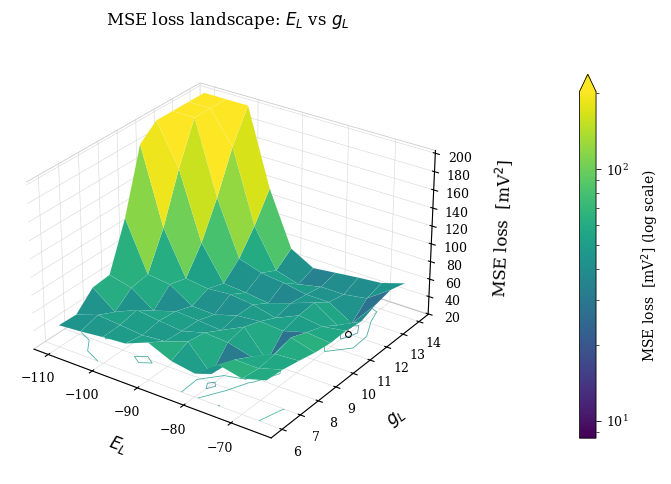

Saved to mse_loss_landscape_3d_E_L_g_L.pdf


In [24]:
# Pick which parameter pair to plot in 3D.
# Accepts either the display name ("C_m") or the internal name ("capacitance").
x_param = "E_L"
y_param = "g_L"

_ALIAS = {"C_m": "capacitance"}
x_key = _ALIAS.get(x_param, x_param)
y_key = _ALIAS.get(y_param, y_param)

if x_key not in PARAM_NAMES:
    raise KeyError(f"Unknown x param {x_param!r}; available: {PARAM_NAMES}")
if y_key not in PARAM_NAMES:
    raise KeyError(f"Unknown y param {y_param!r}; available: {PARAM_NAMES}")
if x_key == y_key:
    raise ValueError("x_param and y_param must differ")

pi, pj = PARAM_NAMES.index(x_key), PARAM_NAMES.index(y_key)

# `grids` only stores pairs with the first index < second (from combinations()).
# If the user picked the reversed order, fetch the stored grid and transpose so
# that the plotted X axis corresponds to x_param.
if (pi, pj) in grids:
    g = grids[(pi, pj)]
    X, Y, Z = g["X"], g["Y"], g["Z"]
else:
    g = grids[(pj, pi)]
    X, Y, Z = g["Y"].T, g["X"].T, g["Z"].T

xlabel = PARAM_LABELS[x_key]
ylabel = PARAM_LABELS[y_key]

# Clip to the same range used in the triangle grid so the 3D surface uses the
# same perceptual scale as the overview figure.
Z_plot = np.clip(Z, vmin, vmax_clip)
log_norm = LogNorm(vmin=vmin, vmax=vmax_clip)
facecolors = cm.viridis(log_norm(Z_plot))

# Default-parameter anchor: the minimum visible on the actual grid.
x0 = initial_params[_map_name_to_initial(x_key)]
y0 = initial_params[_map_name_to_initial(y_key)]

with plt.rc_context({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
}):
    fig = plt.figure(figsize=(7.0, 5.5))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(
        X,
        Y,
        Z_plot,
        facecolors=facecolors,
        rstride=1,
        cstride=1,
        linewidth=0.15,
        edgecolor=(1, 1, 1, 0.25),
        antialiased=True,
        shade=False,
    )

    # Contour projection on the floor, matching the surface's log color scale.
    z_floor = float(np.nanmin(Z_plot)) - 0.05 * (
        float(np.nanmax(Z_plot)) - float(np.nanmin(Z_plot))
    )
    ax.set_zlim(z_floor, float(np.nanmax(Z_plot)))
    contour_levels = np.geomspace(vmin, vmax_clip, 12)
    ax.contour(
        X,
        Y,
        Z_plot,
        levels=contour_levels,
        zdir="z",
        offset=z_floor,
        cmap="viridis",
        norm=log_norm,
        linewidths=0.6,
        alpha=0.8,
    )

    # Drop a thin marker line from the default parameters down to the floor.
    try:
        from scipy.interpolate import RegularGridInterpolator
        interp = RegularGridInterpolator(
            (Y[:, 0], X[0, :]), Z_plot, bounds_error=False, fill_value=np.nan
        )
        z0 = float(interp([[y0, x0]])[0])
        if np.isfinite(z0):
            ax.plot(
                [x0, x0], [y0, y0], [z_floor, z0],
                color="black", linewidth=0.8, alpha=0.7,
            )
            ax.scatter(
                [x0], [y0], [z0],
                s=28, facecolor="white", edgecolor="black", linewidth=0.8, zorder=5,
            )
    except Exception:
        pass
    ax.scatter(
        [x0], [y0], [z_floor],
        s=18, facecolor="white", edgecolor="black", linewidth=0.8, zorder=5,
    )

    ax.set_xlabel(xlabel, labelpad=8)
    ax.set_ylabel(ylabel, labelpad=8)
    ax.set_zlabel(rf"{loss_name} loss  [mV$^2$]", labelpad=8)

    # Clean pane backgrounds — white panes, subtle grid, thin spines.
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor("white")
        axis.pane.set_edgecolor((0.6, 0.6, 0.6, 0.6))
        axis.pane.set_linewidth(0.6)
        axis._axinfo["grid"].update({"linewidth": 0.4, "color": (0.8, 0.8, 0.8, 0.8)})

    ax.tick_params(axis="both", which="major", pad=2, length=2.5, width=0.6)
    ax.view_init(elev=28, azim=-55)
    ax.set_box_aspect((1.0, 1.0, 0.65))

    # Colorbar anchored on the right with log-decade ticks, matching fig. 4.
    mappable = cm.ScalarMappable(norm=log_norm, cmap="viridis")
    mappable.set_array(Z_plot)
    cbar = fig.colorbar(
        mappable, ax=ax, shrink=0.7, pad=0.2, aspect=22, extend="max"
    )
    lo = int(np.floor(np.log10(vmin)))
    hi = int(np.ceil(np.log10(vmax_clip)))
    cbar.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=(hi - lo + 1)))
    cbar.ax.yaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(2, 10), numticks=50)
    )
    cbar.ax.yaxis.set_major_formatter(LogFormatterSciNotation(base=10))
    cbar.ax.tick_params(which="major", labelsize=9, length=3.5, width=0.6)
    cbar.ax.tick_params(which="minor", length=2.0, width=0.5)
    cbar.outline.set_linewidth(0.6)
    cbar.set_label(rf"{loss_name} loss  [mV$^2$] (log scale)", fontsize=10, labelpad=8)

    ax.set_title(f"{loss_name} loss landscape: {xlabel} vs {ylabel}", pad=10)

    fig.tight_layout()
    plt.savefig(
        f"{loss_name.lower()}_loss_landscape_3d_{x_key}_{y_key}.pdf",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    print(
        f"Saved to {loss_name.lower()}_loss_landscape_3d_{x_key}_{y_key}.pdf"
    )
